# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [49]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [50]:
df = pd.read_csv(r'C:\Users\Renad\Downloads\Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [51]:
print(df.columns)

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='str')


### Step 2.a Assign variables `X` to the features and `y` to the target

In [52]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

### Step 2.b print the type of each

In [53]:
print(f"X type: {type(X)}")
print(f"y type: {type(y)}")

X type: <class 'pandas.DataFrame'>
y type: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [54]:
if y.dtype in ['float64', 'int64']:
    print("Target is: Numerical")
    print("Task is: Regression")
else:
    print("Target is: Categorical")
    print("Task is: Classification")

Target is: Numerical
Task is: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [55]:
print(f"Number of samples in X: {X.shape[0]}")
print(f"Number of columns (features) in X: {X.shape[1]}")

print(f"Number of samples in y: {y.shape[0]}")

Number of samples in X: 200
Number of columns (features) in X: 3
Number of samples in y: 200


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [56]:
summary = df.describe().loc[['min', 'max', '50%', 'mean', 'std']]
summary = summary.rename(index={'50%': 'median'})
print(summary)

        Unnamed: 0          TV      radio   newspaper      sales
min       1.000000    0.700000   0.000000    0.300000   1.600000
max     200.000000  296.400000  49.600000  114.000000  27.000000
median  100.500000  149.750000  22.900000   25.750000  12.900000
mean    100.500000  147.042500  23.264000   30.554000  14.022500
std      57.879185   85.854236  14.846809   21.778621   5.217457


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [57]:
feature_ranges = X.max() - X.min()

print("Feature-wise range differences:")
print(feature_ranges)
print("\nObservations:")
print(f"The range for TV is {feature_ranges['TV']:.2f}, while for radio it is {feature_ranges['radio']:.2f}.")
print("There is a significant difference in scale, which is why we need StandardScaler later.")

Feature-wise range differences:
TV           295.7
radio         49.6
newspaper    113.7
dtype: float64

Observations:
The range for TV is 295.70, while for radio it is 49.60.
There is a significant difference in scale, which is why we need StandardScaler later.


### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

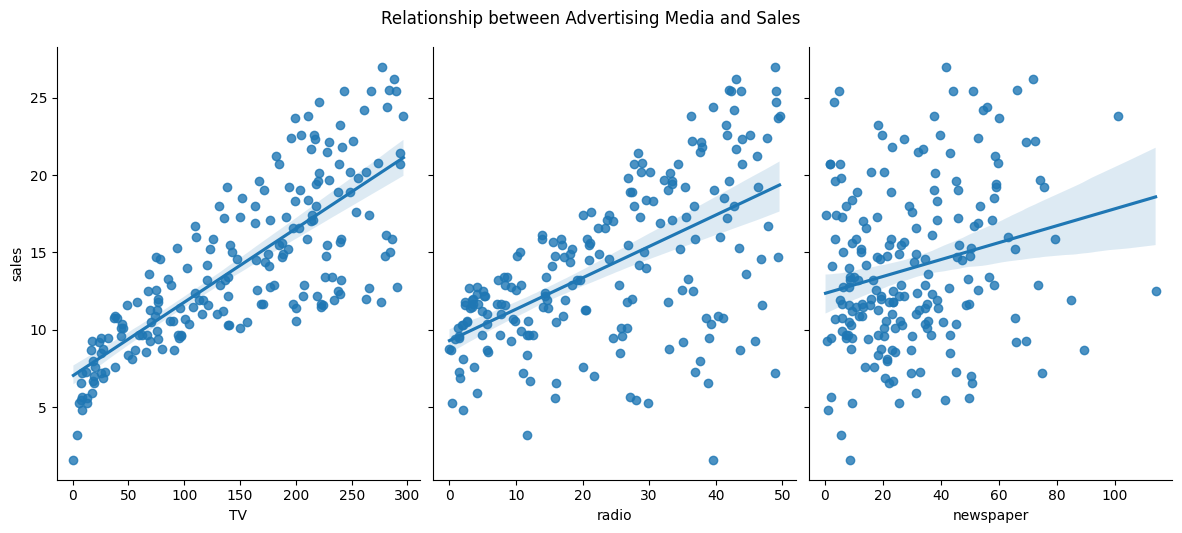

In [58]:
sns.pairplot(df, 
             x_vars=['TV', 'radio', 'newspaper'], 
             y_vars='sales', 
             height=5, 
             aspect=0.8, 
             kind='reg')

# تحسين مظهر الرسم وعرضه
plt.suptitle("Relationship between Advertising Media and Sales", y=1.05)
plt.show()

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

In [59]:
correlations = df[['TV', 'radio', 'newspaper', 'sales']].corr()['sales']

print("Correlation with Sales:")
print(correlations)
print("\n--- Analysis ---")
print(f"x=TV and y=sales: Increasing (Correlation: {correlations['TV']:.2f})")
print(f"x=radio and y=sales: Increasing (Correlation: {correlations['radio']:.2f})")
print(f"x=newspaper and y=sales: None/Weak (Correlation: {correlations['newspaper']:.2f})")

Correlation with Sales:
TV           0.782224
radio        0.576223
newspaper    0.228299
sales        1.000000
Name: sales, dtype: float64

--- Analysis ---
x=TV and y=sales: Increasing (Correlation: 0.78)
x=radio and y=sales: Increasing (Correlation: 0.58)
x=newspaper and y=sales: None/Weak (Correlation: 0.23)


### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [60]:
pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        
        ("scaler", StandardScaler()),
        
        ("regressor", LinearRegression()),
    ])

print("Pipeline has been defined successfully.")





Pipeline has been defined successfully.


### Step 8. Split the dataset into train and test sets

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total samples: 200
Training samples: 160
Testing samples: 40


### Step 9.a Fit the pipeline on the training set

In [62]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [64]:
regressor = pipe.named_steps['regressor']
print(f"Bias term (Intercept): {regressor.intercept_:.4f}")
print(f"TV Coefficient: {regressor.coef_[0]:.4f}")
print(f"Radio Coefficient: {regressor.coef_[1]:.4f}")
print(f"Newspaper Coefficient: {regressor.coef_[2]:.4f}")

Bias term (Intercept): 14.1000
TV Coefficient: 3.7642
Radio Coefficient: 2.7923
Newspaper Coefficient: 0.0560


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [65]:
raw_model = LinearRegression().fit(X_train, y_train)
tv_coef = raw_model.coef_[0]

print(f"For every $1,000 spent on TV, Sales increase by approximately: {tv_coef:.4f} units (in thousands)")

For every $1,000 spent on TV, Sales increase by approximately: 0.0447 units (in thousands)


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [66]:
radio_coef = raw_model.coef_[1]
newspaper_coef = raw_model.coef_[2]

difference = (radio_coef * 5) - (newspaper_coef * 5)

print(f"The difference in Sales if we move $5,000 to Radio: {difference:.4f} units (in thousands)")

The difference in Sales if we move $5,000 to Radio: 0.9322 units (in thousands)


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

In [ ]:
intercept = raw_model.intercept_
print(f"Estimated Sales with zero advertising budget: {intercept:.4f} units (in thousands)")

### Step 10. Evaluate the pipeline on the test set

In [63]:
score = pipe.score(X_test, y_test)

### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [67]:
raw_model = LinearRegression()
raw_model.fit(X_train, y_train)

raw_score = raw_model.score(X_test, y_test)

pipeline_score = pipe.score(X_test, y_test)

print(f"Pipeline Score (with Scaling): {pipeline_score:.6f}")
print(f"Raw Model Score (no Scaling):  {raw_score:.6f}")

if abs(pipeline_score - raw_score) < 1e-10:
    print("\nConclusion: Both scores are identical (or extremely similar).")
else:
    print("\nConclusion: There is a difference in scores.")

Pipeline Score (with Scaling): 0.899438
Raw Model Score (no Scaling):  0.899438

Conclusion: Both scores are identical (or extremely similar).
